# Exercise 7: June 17, 2025

# Solving differential equations with the Euler Method and Runge-Kutta Method

# The Euler Method

**Question 1.** Write a code that will use the Euler method to solve the equation:

$\frac{dy}{dx}=y$

with $y=1$ and $x=0$ over the range from $x=0$ to $x=10$. This is the same problem we worked with in the lecture notebook, but I want you to solve it over a much larger $x$ range and number of timesteps.

The example function `euler_solver` I gave in the lecture notebook only stepped forward one step at a time. Build an improved function that reads in the initial value ($y$ and $x=0$) and the ending point to solve to ($x=10$ for this question) and returns a full array with the solution $y$ and $x$ so we can plot the solution as a function of $x$.

Use a step size of $h=0.1$. Plot your numerical answer and the exact solution, which is: $y=e^x$. Calculate the average percent error for your numerical solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def euler(y1, x1, x_e, h, lam):
  x = [x1]
  y = [y1]
  for i in range(0, (x_e)):
    x.append(x[i] + h)
    y.append(y[i] + h*y[i]*lam)
  return np.array(x), np.array(y)

In [3]:
def p_error(model, exact):
  if exact > 0:
    error = (abs((model-exact)/exact)*100)
  else:
    error = 0
  return error

error: 2.3068880400542096


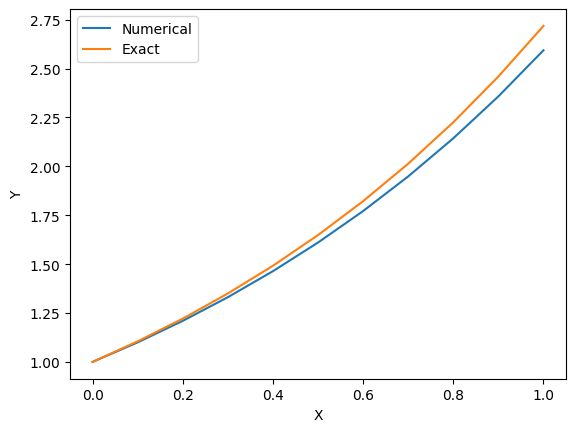

In [4]:
euler(1,0,10,0.1,1)
x = euler(1,0,10,0.1,1)[0]
y = euler(1,0,10,0.1,1)[1]
exact = np.exp(x)

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()

**Question 2.** Try changing the step size, $h$. How low do you have to make $h$ in order to get the average percent error down to less than 1%?

error: 0.8603254398689985


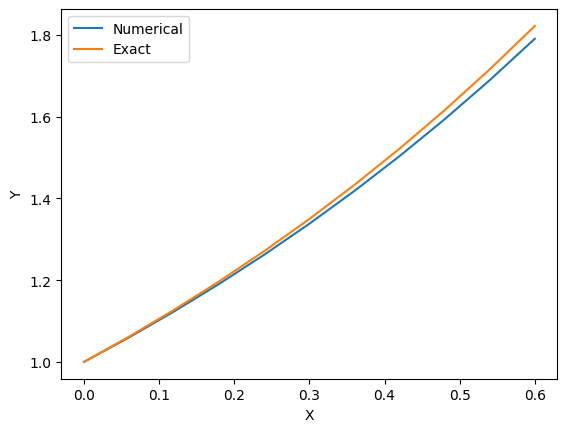

In [5]:
euler(1,0,10,0.06,1)
x = euler(1,0,10,0.06,1)[0]
y = euler(1,0,10,0.06,1)[1]
exact = np.exp(x)

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()

**Question 3.** Now try the equation:

$\frac{dy}{dx} = -10y$

with $y=5$ and $x=0$, where the exact solution is

$y=5e^{-10x}$. Solve this over the interval $x=0$ to $x=10$. Calculate the percent error and see how small you need to make the step size to get the average percent error below 1%.

error: 0.931576979214763


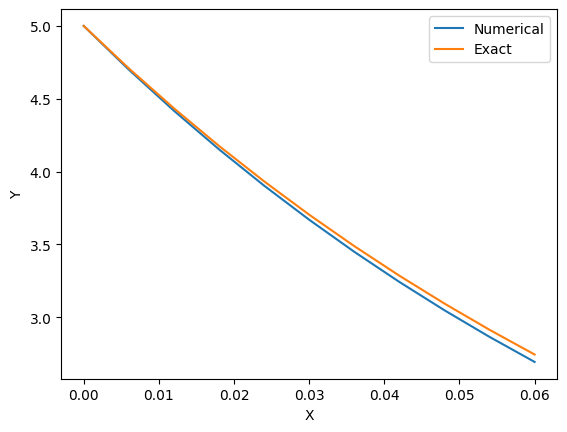

In [6]:
euler(5,0,10,.006,-10)
x = euler(5,0,10,.006,-10)[0]
y = euler(5,0,10,.006,-10)[1]
exact = 5*np.exp(-10*x)

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()

**Question 4.** Now solve the equation

$\frac{dy}{dx} = \sin{(x)}^2y$,

with $y=1$ and $x=0$ from $x=0$ to $x=10$

The exact solution is:

$y=e^{(\frac{1}{2}[x-\sin{(x)}\cos{(x)}])}$

Calculate percent error and find the step size you need to keep the average percent error below 1%.

In [7]:
def euler2(y1, x1, x_e, h, lam):
  x = [x1]
  y = [y1]
  for i in range(0, (x_e)):
    x.append(x[i] + h)
    y.append(y[i] + h*(np.sin(x[i])**2*(y[i]))*lam)
  return np.array(x), np.array(y)

error: 0.8222491429428661


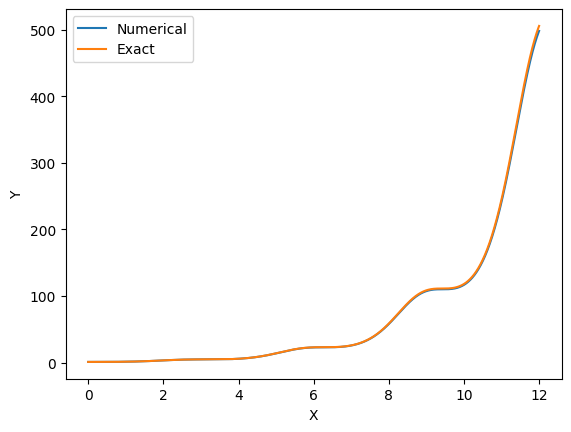

In [8]:
x_e = 10
h = 0.005
step = int(x_e/h)

euler2(1,0,step,.006,1)
x = euler2(1,0,step,.006,1)[0]
y = euler2(1,0,step,.006,1)[1]
exact = np.exp((1/2)*(x-np.sin(x)*np.cos(x)))

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()

# Using the Runge-Kutta Method

We'll solve the same equations but now using the Runge-Kutta method.

**Question 5.** Solve

$\frac{dy}{dx}=y$

with $y=1$ and $x=0$ over the range from $x=0$ to $x=10$ using the Runge-Kutta method. You will need to write a function similar to the one you used for the first 4 questions, but revised to use the Runge-Kutta method instead.

Change the step size to find the largest step size you can use and still have the average percent error less than 1% (you don't have to find this exactly, just use some trial and error until you get pretty close to, but just under, 1%)

In [9]:
def RK(y1, x1, x_e, h, lam):
  x = [x1]
  y = [y1]
  for i in range(0, (x_e)):
    x.append(x[i] + h)
    k1 = lam*y[i]
    k2 = lam*(y[i]+(h*k1)/2)
    k3 = lam*(y[i]+(h*k2)/2)
    k4 = lam*(y[i]+(h*k3))
    y.append(y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4))
  return np.array(x), np.array(y)

error: 0.9997600399894891


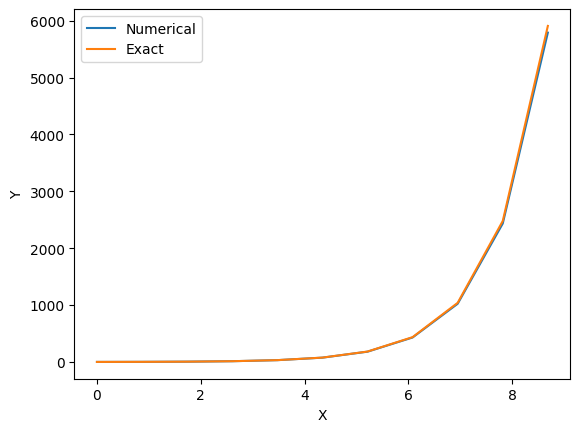

In [10]:
RK(1,0,10,.8684,1)
x = RK(1,0,10,.8684,1)[0]
y = RK(1,0,10,.8684,1)[1]
exact = np.exp(x)

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()

**Question 6.** Now solve the equation:

$\frac{dy}{dx} = -10y$

with $y=5$ and $x=0$, over the interval $x=0$ to $x=10$. Again the exact solution is $y=5e^{-10x}$.

Calculate the percent error and see how small you need to make the step size to get the average percent error below 1%.

error: 0.9999667908888863


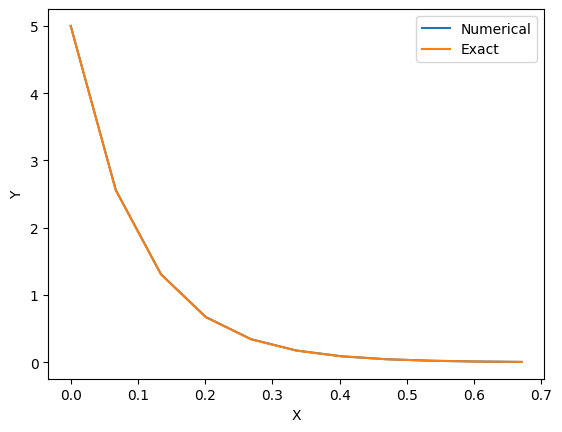

In [11]:
RK(5,0,10,.06708,-10)
x = RK(5,0,10,.06708,-10)[0]
y = RK(5,0,10,.06708,-10)[1]
exact = 5*np.exp((-10)*x)

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()

**Question 7.** Lastly, solve the equation

$\frac{dy}{dx} = \sin{(x)}^2y$,

with $y=1$ and $x=0$ from $x=0$ to $x=15$ again, now using Runge-Kutta. Find the step size that gives an average percent error just below 1%.

For these three equations we solved, how did the step size needed to get <1% error with the Euler Method compare to the step sizes needed for that same accuracy with the Runge-Kutta method?

In [12]:
def RK2(y1, x1, x_e, h, lam):
  x = [x1]
  y = [y1]
  for i in range(0, (x_e)):
    x.append(x[i] + h)
    k1 = lam*((np.sin(x[i])**2*(y[i])))
    k2 = lam*((np.sin(x[i])**2*(y[i]))+(h*k1)/2)
    k3 = lam*((np.sin(x[i])**2*(y[i]))+(h*k2)/2)
    k4 = lam*((np.sin(x[i])**2*(y[i]))+(h*k3))
    y.append(y[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4))
  return np.array(x), np.array(y)

error: 0.9974821109985544


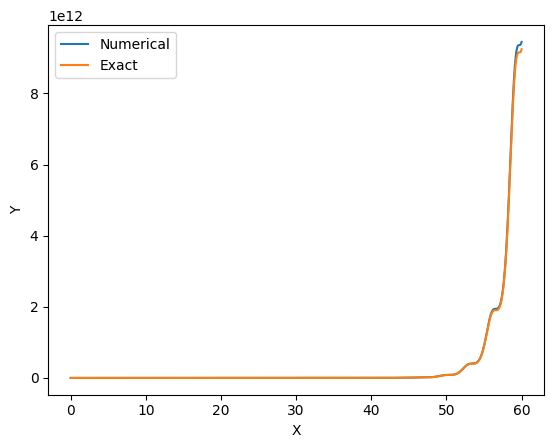

In [13]:
x_e = 15
h = 0.0015
step = int(x_e/h)

RK2(1,0,step,.006,1)
x = RK2(1,0,step,.006,1)[0]
y = RK2(1,0,step,.006,1)[1]
exact = np.exp((1/2)*(x-np.sin(x)*np.cos(x)))

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()

error: 0.23312197778647442


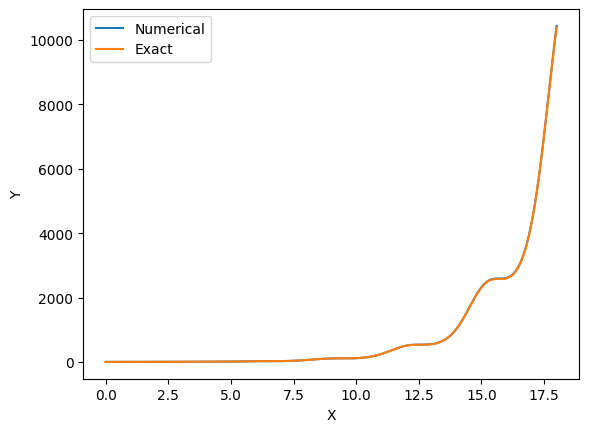

In [14]:
x_e = 15
h = 0.005
step = int(x_e/h)

RK2(1,0,step,.006,1)
x = RK2(1,0,step,.006,1)[0]
y = RK2(1,0,step,.006,1)[1]
exact = np.exp((1/2)*(x-np.sin(x)*np.cos(x)))

error1 = []
for i in range(len(y)):
  error1.append(p_error(y[i], exact[i]))
print("error:", (np.average(error1)))

plt.plot(x,y, x,exact)
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(("Numerical","Exact"))

plt.show()